In [ ]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Check your location of the dataset and read it into a pandas DataFrame
df = pd.read_csv('../ISLR-Datasets/day.csv', sep=',', header=0)


In [16]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


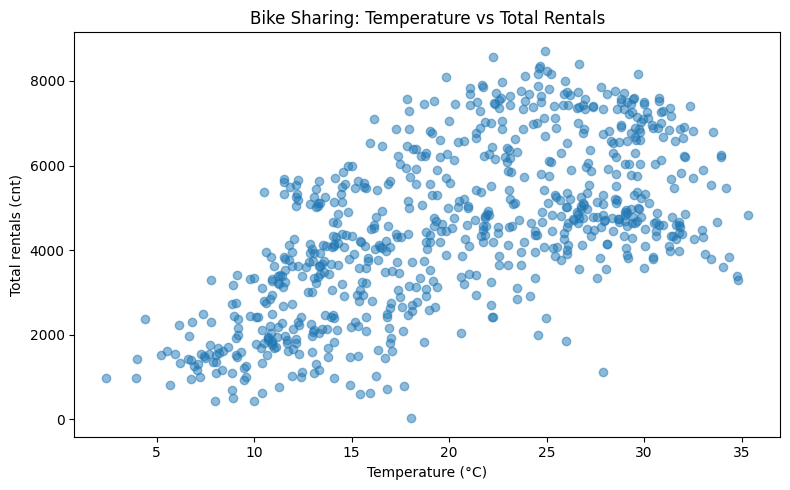

In [17]:
# UCI columns:
# temp is normalized to [0,1]. Convert to Celsius using the dataset convention: temp_C = temp * 41
df["temp_C"] = df["temp"] * 41

plt.figure(figsize=(8,5))
plt.scatter(df["temp_C"], df["cnt"], alpha=0.5)
plt.xlabel("Temperature (°C)")
plt.ylabel("Total rentals (cnt)")
plt.title("Bike Sharing: Temperature vs Total Rentals")
plt.tight_layout()
plt.show()

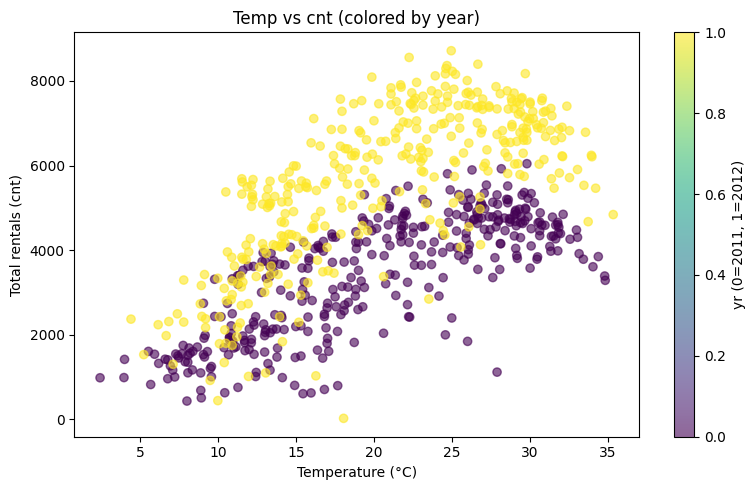

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df["temp_C"], df["cnt"], c=df["yr"], alpha=0.6)
plt.xlabel("Temperature (°C)"); plt.ylabel("Total rentals (cnt)")
plt.title("Temp vs cnt (colored by year)")
plt.colorbar(label="yr (0=2011, 1=2012)")
plt.tight_layout()
plt.show()


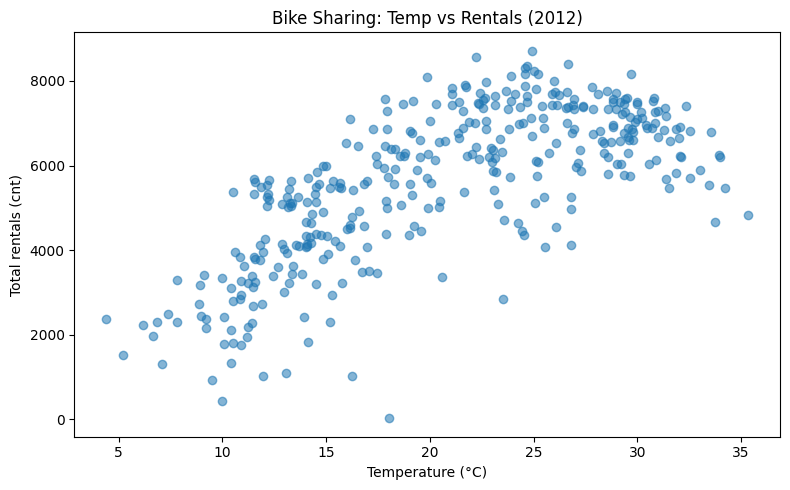

In [19]:
def scatter_with_ols(sub, year_label):
    x = sub["temp_C"].to_numpy()
    y = sub["cnt"].to_numpy()

    # OLS line: y = a + b x
    b, a = np.polyfit(x, y, 1)  # returns slope, intercept (for degree 1)

    # line for plotting
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = a + b * x_line

    plt.figure(figsize=(8,5))
    plt.scatter(x, y, alpha=0.55)
    #plt.plot(x_line, y_line, linewidth=2)
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Total rentals (cnt)")
    plt.title(f"Bike Sharing: Temp vs Rentals ({year_label})")
    plt.tight_layout()
    plt.show()

# UCI:yr = 1 (2012)
scatter_with_ols(df[df["yr"] == 1], "2012")

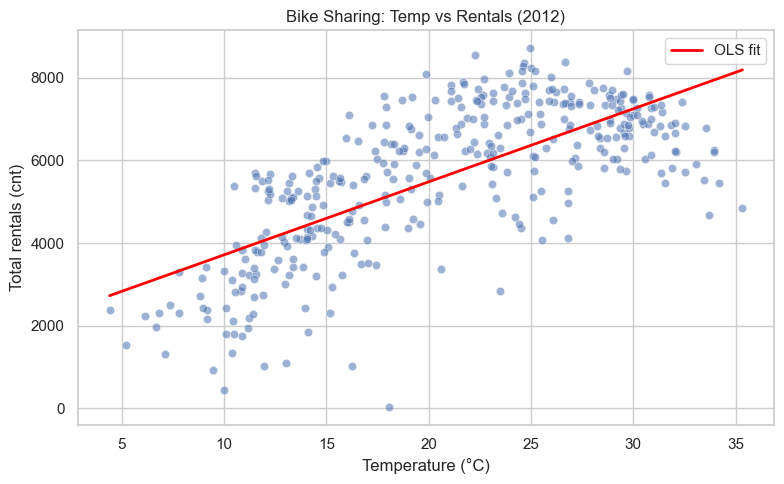

In [20]:
def scatter_with_ols(sub, year_label):
    x = sub["temp_C"].to_numpy()
    y = sub["cnt"].to_numpy()

    # OLS line: y = a + b x
    b, a = np.polyfit(x, y, 1)  # slope, intercept
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = a + b * x_line

    # Seaborn look
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=x, y=y, alpha=0.55)  # seaborn scatter
    plt.plot(x_line, y_line, color="red", linewidth=2, label="OLS fit")

    plt.xlabel("Temperature (°C)")
    plt.ylabel("Total rentals (cnt)")
    plt.title(f"Bike Sharing: Temp vs Rentals ({year_label})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# UCI: yr = 1 (2012)
scatter_with_ols(df[df["yr"] == 1], "2012")

In [21]:
def plot_poly_comparison(sub, x_col, y_col="cnt"):
    x = sub[x_col].to_numpy()
    y = sub[y_col].to_numpy()

    # sort x for smooth lines
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # scatter
    plt.figure(figsize=(9, 5))
    #plt.scatter(x, y, color="tab:blue", alpha=0.5, label="Data")
    sns.scatterplot(x=x, y=y, alpha=0.35, color="0.7", edgecolor=None)

    # grid for smooth fitted curves
    x_grid = np.linspace(x.min(), x.max(), 400)

    # degree 3
    coef_3 = np.polyfit(x, y, deg=3)
    y_grid_3 = np.polyval(coef_3, x_grid)
    plt.plot(x_grid, y_grid_3, color="black", linewidth=2, label="Polynomial (d=3)")

    # degree 15
    coef_15 = np.polyfit(x, y, deg=15)
    y_grid_15 = np.polyval(coef_15, x_grid)
    plt.plot(x_grid, y_grid_15, color="red", linewidth=2, label="Polynomial (d=15)")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Polynomial fit comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_poly_comparison(sub, x_col="temp", y_col="cnt")

NameError: name 'sub' is not defined

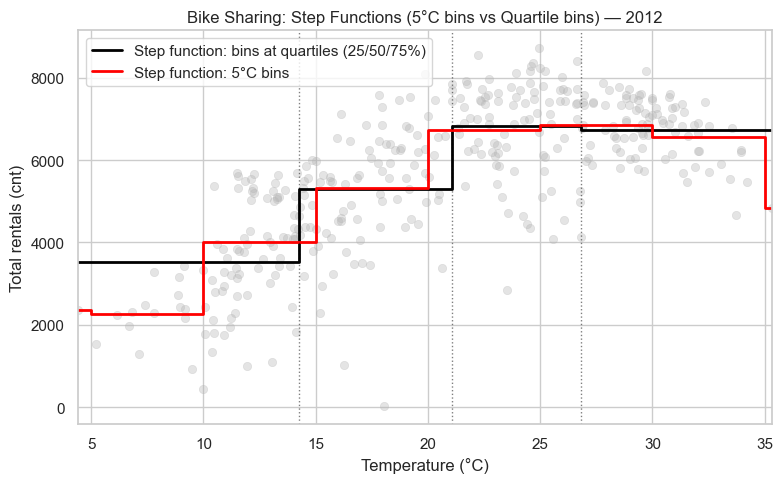

In [ ]:
def step_curve_from_bins(x, y, edges):
    """
    Build a piecewise-constant step curve (bin means) given bin edges.
    Returns x_step, y_step suitable for plt.step(where='post').
    """
    x_step, y_step = [], []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        mask = (x >= lo) & (x < hi) if i < len(edges) - 2 else (x >= lo) & (x <= hi)
        if mask.sum() == 0:
            continue
        mean = float(np.mean(y[mask]))
        x_step += [lo, hi]
        y_step += [mean, mean]
    return np.array(x_step), np.array(y_step)

def plot_two_step_functions(sub, year_label="2012"):
    x = sub["temp_C"].to_numpy()
    y = sub["cnt"].to_numpy()

    xmin, xmax = float(x.min()), float(x.max())

    # --- (1) 5°C bins ---
    edges_5 = np.arange(np.floor(xmin/5)*5, np.ceil(xmax/5)*5 + 5, 5.0)
    x5, y5 = step_curve_from_bins(x, y, edges_5)

    # --- (2) Quartile bins (25%, 50%, 75%) ---
    q = np.quantile(x, [0.25, 0.5, 0.75])
    edges_q = np.array([xmin, *q, xmax], dtype=float)
    xq, yq = step_curve_from_bins(x, y, edges_q)

    # Plot
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=x, y=y, alpha=0.35, color="0.7", edgecolor=None)

    # Quartile step (black)
    plt.step(
        xq, yq, where="post", color="black", linewidth=2,
        label="Step function: bins at quartiles (25/50/75%)"
    )

    # 5°C step (red)
    plt.step(
        x5, y5, where="post", color="red", linewidth=2,
        label="Step function: 5°C bins"
    )

    # Optional: show quartile cut lines
    for cut in q:
        plt.axvline(float(cut), color="black", linestyle=":", linewidth=1, alpha=0.5)

    plt.xlabel("Temperature (°C)")
    plt.ylabel("Total rentals (cnt)")
    plt.title(f"Bike Sharing: Step Functions (5°C bins vs Quartile bins) — {year_label}")
    plt.xlim(xmin, xmax)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example (same as before)
plot_two_step_functions(df[df["yr"] == 1], year_label="2012")

/var/folders/94/0smbyrv170s487c4bf6hd4800000gn/T/ipykernel_59843/588753882.py:24: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spl_low  = UnivariateSpline(x, y, k=3, s=s_low)


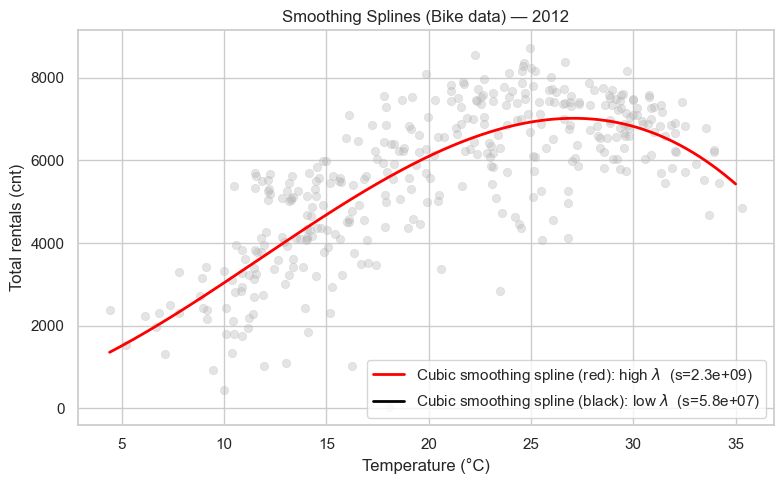

In [ ]:
def plot_smoothing_splines_lambda(sub, year_label="2012"):
    x = sub["temp_C"].to_numpy()
    y = sub["cnt"].to_numpy()

    # sort for spline fitting
    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    # grid only over observed range (cap at ~35°C if you want)
    x_upper = min(float(x.max()), 35.0)
    x_grid = np.linspace(float(x.min()), x_upper, 400)

    # Smoothing spline (cubic) via UnivariateSpline: uses smoothing factor 's'
    # We interpret: higher lambda -> smoother -> larger s
    from scipy.interpolate import UnivariateSpline

    n = len(x)
    var_y = float(np.var(y))

    # Choose two smoothing levels (tweak multipliers if you want more separation)
    s_low  = 0.05 * n * var_y   # low lambda (wigglier)
    s_high = 2.00 * n * var_y   # high lambda (smoother)

    spl_low  = UnivariateSpline(x, y, k=3, s=s_low)
    spl_high = UnivariateSpline(x, y, k=3, s=s_high)

    y_low  = spl_low(x_grid)
    y_high = spl_high(x_grid)

    plt.figure(figsize=(8, 5))
    # grey points like the textbook
    sns.scatterplot(x=x, y=y, alpha=0.35, color="0.7", edgecolor=None)

    # High lambda (smooth) in red
    plt.plot(x_grid, y_high, color="red", linewidth=2,
             label=rf"Cubic smoothing spline (red): high $\lambda$  (s={s_high:.2g})")

    # Low lambda (wiggly) in black
    plt.plot(x_grid, y_low, color="black", linewidth=2,
             label=rf"Cubic smoothing spline (black): low $\lambda$  (s={s_low:.2g})")

    plt.xlabel("Temperature (°C)")
    plt.ylabel("Total rentals (cnt)")
    plt.title(f"Smoothing Splines (Bike data) — {year_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: 2012 subset
plot_smoothing_splines_lambda(df[df["yr"] == 1], year_label="2012")

In [ ]:
def poly15_vs_natural_spline15(df_sub, year_label="2012"):
    x = df_sub["temp_C"].to_numpy()
    y = df_sub["cnt"].to_numpy()

    # Sort for clean lines
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    # Plot grid: only within observed range (cap at 35°C like before if you want)
    x_upper = 35.9
    x_grid = np.linspace(float(x.min()), x_upper, 500)

    # -------------------------
    # 1) Polynomial regression (degree 15)
    # -------------------------
    # Replace your polynomial block with this
    x_mean, x_std = x.mean(), x.std()
    z = (x - x_mean) / x_std
    z_grid = (x_grid - x_mean) / x_std

    Z_poly = np.column_stack([z**k for k in range(16)])
    beta, *_ = np.linalg.lstsq(Z_poly, y, rcond=None)

    Zg_poly = np.column_stack([z_grid**k for k in range(16)])
    y_poly = Zg_poly @ beta

    # -------------------------
    # 2) Natural cubic spline with ~15 df
    # -------------------------
    # In this basis, df roughly equals number of features produced.
    # With include_bias=False, n_knots=15 gives (n_knots + degree - 1) = 17 features for degree=3.
    # So we set n_knots=13 to get 15 features: 13 + 3 - 1 = 15.
    n_knots = 13  # -> 15 features when degree=3 and include_bias=False

    spline = SplineTransformer(
        degree=3,
        n_knots=n_knots,
        knots="quantile",
        include_bias=False,
        extrapolation="linear"  # natural-like linear tails
    )
    spline_model = make_pipeline(spline, LinearRegression())
    spline_model.fit(x.reshape(-1, 1), y)
    y_spline = spline_model.predict(x_grid.reshape(-1, 1))

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=x, y=y, alpha=0.45, color="0.7", edgecolor=None)  # grey points
    plt.plot(x_grid, y_spline, color="red", linewidth=2, label="Natural cubic spline (~15 df)")
    plt.plot(x_grid, y_poly, color="blue", linewidth=2, label="Polynomial (d=15)")

    plt.xlabel("Temperature (°C)")
    plt.ylabel("Total rentals (cnt)")
    plt.title(f"Bike Sharing: d=15 Polynomial vs Natural Cubic Spline (~15 df) — {year_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: 2012 subset (same as your earlier work)
poly15_vs_natural_spline15(df[df["yr"] == 1], "2012")

KeyError: 'temp_C'